<a href="https://colab.research.google.com/github/tomasricardo1999/python-showcase/blob/main/World-Bank-Data-Analysis/World_Population_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Population Analysis

🌍 **Project Objectives — Population Indicators via API & Python**


🚀 Demonstrate Practical API Skills
* Show how Python can interact with real external APIs (World Bank Indicators API) to retrieve population data used in official country dashboards, such as the “Population, total” values.  

🌐 Collect Multiple Demographic Indicators

* Work with gender, age‑structure, and urbanization metrics included in the World Development Indicators “People” theme, which covers population composition and related demographic data.  

🗂 Process & Store Data Effectively

* Use pandas to clean API responses, structure them into tables, and prepare datasets ready for analysis.

📊 Create Clear Visualizations

* Build visual comparisons and trend analyses across different population indicators and countries.

🧠 Turn Data Into Insights

* Translate raw population numbers into meaningful observations about demographic and social evolution.

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def get_real_countries():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    r = requests.get(url)
    data = r.json()
    records = data[1]

    countries = [c["id"] for c in records if c["region"]["id"] != "NA"]
    return sorted(countries)

real_countries = get_real_countries()

print(f"\nTotal real countries: {len(real_countries)}")
print("Countries (ISO‑3 codes):")
for i, code in enumerate(real_countries, start=1):
    print(f"{i:3}. {code}")



Total real countries: 217
Countries (ISO‑3 codes):
  1. ABW
  2. AFG
  3. AGO
  4. ALB
  5. AND
  6. ARE
  7. ARG
  8. ARM
  9. ASM
 10. ATG
 11. AUS
 12. AUT
 13. AZE
 14. BDI
 15. BEL
 16. BEN
 17. BFA
 18. BGD
 19. BGR
 20. BHR
 21. BHS
 22. BIH
 23. BLR
 24. BLZ
 25. BMU
 26. BOL
 27. BRA
 28. BRB
 29. BRN
 30. BTN
 31. BWA
 32. CAF
 33. CAN
 34. CHE
 35. CHI
 36. CHL
 37. CHN
 38. CIV
 39. CMR
 40. COD
 41. COG
 42. COL
 43. COM
 44. CPV
 45. CRI
 46. CUB
 47. CUW
 48. CYM
 49. CYP
 50. CZE
 51. DEU
 52. DJI
 53. DMA
 54. DNK
 55. DOM
 56. DZA
 57. ECU
 58. EGY
 59. ERI
 60. ESP
 61. EST
 62. ETH
 63. FIN
 64. FJI
 65. FRA
 66. FRO
 67. FSM
 68. GAB
 69. GBR
 70. GEO
 71. GHA
 72. GIB
 73. GIN
 74. GMB
 75. GNB
 76. GNQ
 77. GRC
 78. GRD
 79. GRL
 80. GTM
 81. GUM
 82. GUY
 83. HKG
 84. HND
 85. HRV
 86. HTI
 87. HUN
 88. IDN
 89. IMN
 90. IND
 91. IRL
 92. IRN
 93. IRQ
 94. ISL
 95. ISR
 96. ITA
 97. JAM
 98. JOR
 99. JPN
100. KAZ
101. KEN
102. KGZ
103. KHM
104. KIR
105. KNA
106

In [ ]:
def get_worldbank_timeseries(indicator,
                             countries= real_countries):
    """
    Retrieve time-series data from the World Bank Indicators API
    for the specified indicator and countries.

    Parameters
    ----------
    indicator : str
        World Bank indicator code (e.g. "SP.POP.TOTL").
    countries : list of str
        List of ISO-3 country codes.

    Returns
    -------
    pandas.DataFrame
        Years as index, countries as columns.
    """

    base_url = "https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"
    country_str = ";".join(countries)

    url = base_url.format(countries=country_str, indicator=indicator)
    params = {"format": "json", "per_page": 20000}

    # Request data
    r = requests.get(url, params=params)
    r.raise_for_status()

    data = r.json()
    records = data[-1]  # last element contains observations

    # Normalize JSON into DataFrame
    df = pd.json_normalize(records)

    # Keep relevant fields: date, value, and country code
    df = df[["date", "countryiso3code", "value"]]

    # Pivot to time series format
    df = df.pivot_table(values="value",
                        index="date",
                        columns="countryiso3code")

    # Sort by year ascending and convert index to int
    df.index = df.index.astype(int)
    df = df.sort_index()

    return df


In [ ]:
pop = get_worldbank_timeseries("SP.POP.TOTL")
print (pop)

countryiso3code       ABW         AFG         AGO        ALB      AND  \
date                                                                    
1960              54922.0   9035043.0   5231654.0  1608800.0   9510.0   
1961              55578.0   9214083.0   5301583.0  1659800.0  10283.0   
1962              56320.0   9404406.0   5354310.0  1711319.0  11086.0   
1963              57002.0   9604487.0   5408320.0  1762621.0  11915.0   
1964              57619.0   9814318.0   5464187.0  1814135.0  12764.0   
...                   ...         ...         ...        ...      ...   
2020             108587.0  39068979.0  33451132.0  2528480.0  77380.0   
2021             107700.0  40000412.0  34532429.0  2489762.0  78364.0   
2022             107310.0  40578842.0  35635029.0  2451636.0  79705.0   
2023             107359.0  41454761.0  36749906.0  2414095.0  80856.0   
2024             107995.0  42647492.0  37885849.0  2377128.0  81938.0   

countryiso3code         ARE         ARG        ARM

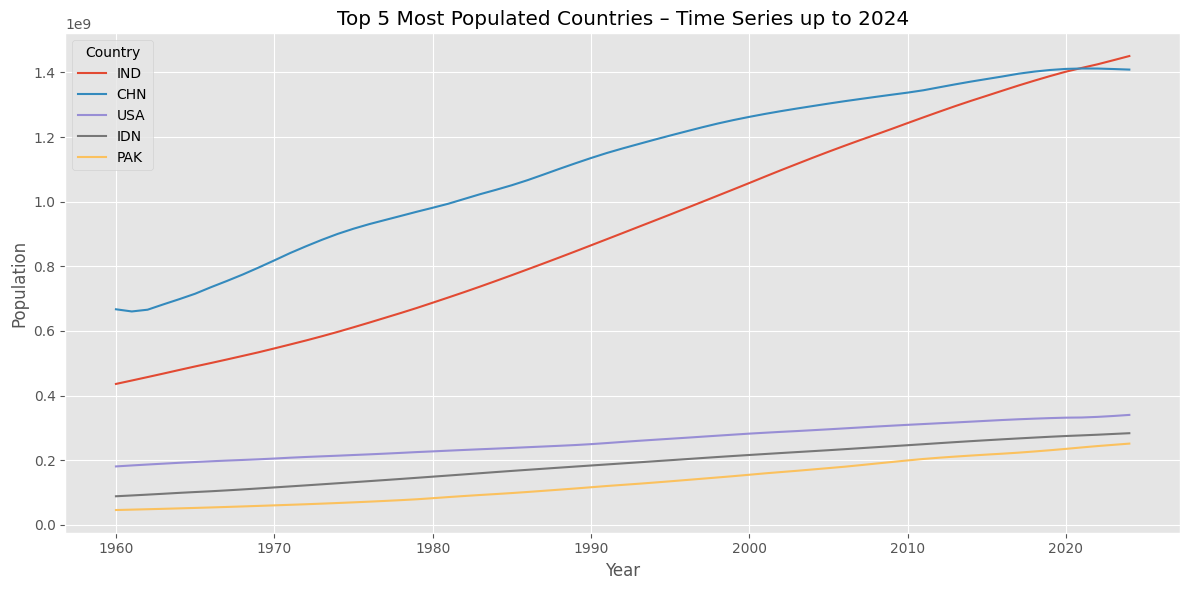

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Apply ggplot style
plt.style.use("ggplot")

# ---- Use your existing dataframe df_all ----
# df_all = get_worldbank_timeseries_all_countries("SP.POP.TOTL")

# 1. Pick the last available year
last_year = pop.index.max()

# 2. Extract the row for that year
last_year_values = pop.loc[last_year]

# 3. Sort countries by population and pick top 5
top5_countries = last_year_values.sort_values(ascending=False).head(5).index.tolist()

# 4. Filter the dataframe to only the top 5 countries
df_top5 = pop[top5_countries]

# 5. Plot
plt.figure(figsize=(12, 6))
for country in top5_countries:
    plt.plot(df_top5.index, df_top5[country], label=country)

plt.title(f"Top 5 Most Populated Countries – Time Series up to {last_year}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(title="Country")
plt.tight_layout()
plt.show()